# Ryan Jacobs Bootstrap Neural-Network PDF Fitter

This notebook trains a PyTorch bootstrap neural-network ensemble to approximate replica-based PDF-style data and compare the original replica uncertainty against the neural-network ensemble uncertainty.

## Essential outputs

This GitHub-ready version includes only the essential graphs similar to the original notebook:

1. Main fit graph: original mean/std band vs neural-network mean/std band
2. Uncertainty comparison graph: original standard deviation vs neural-network ensemble standard deviation

Optional diagnostic figures are not included in the main workflow to keep the notebook clean.

In [ ]:
# ============================================================
# 01. Imports
# ============================================================

import os
import json
import math
import time
import zipfile
import random
from dataclasses import dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

%matplotlib inline

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.grid"] = True

In [ ]:
# ============================================================
# 02. Configuration
# ============================================================

@dataclass
class RunConfig:
    # Update this path if your file is somewhere else.
    zip_path: str = "/content/drive/MyDrive/Colab Notebooks/Summer NN/trey24_no_sidis_lo.zip"
    npy_inside_zip: str = "trey24_no_sidis_lo.npy"

    Q2_value: float = 500
    flavor: str = "uv"

    # Use 20 for faster testing. Change to 100 for the final run.
    n_models: int = 20

    hidden_dim: int = 160
    num_layers: int = 4
    dropout: float = 0.03

    max_epochs: int = 4000
    patience: int = 500
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    grad_clip: float = 1.0

    validation_fraction: float = 0.15
    min_std: float = 1e-8

    output_dir: str = "outputs"
    output_file: str = "Ryan_Jacobs_bootstrap_predictions.npz"


cfg = RunConfig()
os.makedirs(cfg.output_dir, exist_ok=True)

print(json.dumps(asdict(cfg), indent=2))

In [ ]:
# ============================================================
# 03. Reproducibility and device setup
# ============================================================

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
print("PyTorch version:", torch.__version__)

## Load the replica data

This section loads a zipped NumPy file and extracts the selected flavor and Q² block.

In [ ]:
# ============================================================
# 04. Load zipped NumPy data
# ============================================================

def load_pdf_data(zip_path: str, npy_inside_zip: str):
    if not os.path.exists(zip_path):
        raise FileNotFoundError(
            f"Could not find zip file: {zip_path}\n"
            "Update cfg.zip_path to the correct location."
        )

    with zipfile.ZipFile(zip_path, "r") as z:
        names = z.namelist()

        if npy_inside_zip not in names:
            npy_files = [name for name in names if name.endswith(".npy")]

            if len(npy_files) == 1:
                npy_inside_zip = npy_files[0]
                print("Using detected .npy file:", npy_inside_zip)
            else:
                raise FileNotFoundError(
                    f"{npy_inside_zip} was not found inside the zip file. "
                    f"Available .npy files: {npy_files}"
                )

        with z.open(npy_inside_zip) as f:
            obj = np.load(f, allow_pickle=True)

    if isinstance(obj, np.ndarray) and obj.shape == ():
        obj = obj.item()

    return obj


treypdf = load_pdf_data(cfg.zip_path, cfg.npy_inside_zip)

print("Loaded object type:", type(treypdf))

if isinstance(treypdf, dict):
    print("Top-level keys:", list(treypdf.keys())[:20])

In [ ]:
# ============================================================
# 05. Extract selected flavor and Q²
# ============================================================

def extract_pdf_block(pdf_obj, Q2_value, flavor):
    q2_candidates = [
        Q2_value,
        int(Q2_value),
        float(Q2_value),
        str(Q2_value),
        str(int(Q2_value)) if float(Q2_value).is_integer() else str(Q2_value),
    ]

    if isinstance(pdf_obj, dict):
        # Layout A: pdf_obj[Q2][flavor]
        for q2 in q2_candidates:
            if q2 in pdf_obj:
                block = pdf_obj[q2]
                if isinstance(block, dict) and flavor in block:
                    return np.asarray(block[flavor], dtype=np.float64)

        # Layout B: pdf_obj[flavor][Q2]
        if flavor in pdf_obj:
            block = pdf_obj[flavor]
            if isinstance(block, dict):
                for q2 in q2_candidates:
                    if q2 in block:
                        return np.asarray(block[q2], dtype=np.float64)

        # Layout C: numeric-like keys
        for key, value in pdf_obj.items():
            if isinstance(value, dict) and flavor in value:
                try:
                    if float(key) == float(Q2_value):
                        return np.asarray(value[flavor], dtype=np.float64)
                except Exception:
                    pass

    raise KeyError(f"Could not find flavor={flavor} at Q2={Q2_value}.")


data = extract_pdf_block(treypdf, cfg.Q2_value, cfg.flavor)

if data.ndim != 2:
    raise ValueError(f"Expected data shape (n_replicas, n_x_points), got {data.shape}")

print("Selected flavor:", cfg.flavor)
print("Selected Q²:", cfg.Q2_value)
print("Data shape:", data.shape)

## Build reference statistics and neural-network features

In [ ]:
# ============================================================
# 06. Reference statistics and features
# ============================================================

mean = data.mean(axis=0)
std = data.std(axis=0, ddof=1)
std_safe = np.maximum(std, cfg.min_std)

n_original_replicas, n_x = data.shape

x_grid = np.geomspace(1e-4, 1.0, n_x)

x_raw = x_grid
x_log = np.log10(x_grid)

x_raw_norm = 2 * (x_raw - x_raw.min()) / (x_raw.max() - x_raw.min()) - 1
x_log_norm = 2 * (x_log - x_log.min()) / (x_log.max() - x_log.min()) - 1


def make_features(x_raw_norm, x_log_norm, n_fourier=6):
    features = [
        x_raw_norm,
        x_log_norm,
        x_raw_norm ** 2,
        x_log_norm ** 2,
        x_raw_norm * x_log_norm,
    ]

    for k in range(1, n_fourier + 1):
        features.append(np.sin(k * math.pi * x_log_norm))
        features.append(np.cos(k * math.pi * x_log_norm))

    return np.column_stack(features)


X_features = make_features(x_raw_norm, x_log_norm, n_fourier=6)
X_all = torch.tensor(X_features, dtype=torch.float32, device=device)

y_scale = np.max(np.abs(mean))
if y_scale < 1e-12:
    y_scale = 1.0

data_scaled = data / y_scale

print("Original replicas:", n_original_replicas)
print("x points:", n_x)
print("Feature shape:", X_features.shape)
print("Target scale:", y_scale)

## Bootstrap targets and train/validation split

In [ ]:
# ============================================================
# 07. Bootstrap targets and train/validation split
# ============================================================

def create_bootstrap_targets(data_array, n_models, seed=42):
    rng = np.random.default_rng(seed)
    n_replicas = data_array.shape[0]

    targets = []

    for _ in range(n_models):
        idx = rng.choice(n_replicas, size=n_replicas, replace=True)
        sampled = data_array[idx]
        targets.append(sampled.mean(axis=0))

    return np.asarray(targets)


bootstrap_targets = create_bootstrap_targets(data_scaled, cfg.n_models, seed=42)


def make_train_val_split(n_points, validation_fraction=0.15, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(n_points)
    rng.shuffle(indices)

    n_val = max(1, int(validation_fraction * n_points))

    val_idx = np.sort(indices[:n_val])
    train_idx = np.sort(indices[n_val:])

    return train_idx, val_idx


train_idx, val_idx = make_train_val_split(
    n_x,
    validation_fraction=cfg.validation_fraction,
    seed=42,
)

X_train = X_all[train_idx]
X_val = X_all[val_idx]

print("Bootstrap target shape:", bootstrap_targets.shape)
print("Train points:", len(train_idx))
print("Validation points:", len(val_idx))

## PyTorch neural network

In [ ]:
# ============================================================
# 08. Model definition
# ============================================================

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.03):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )

        self.norm = nn.LayerNorm(dim)
        self.act = nn.SiLU()

    def forward(self, x):
        return self.act(self.norm(x + self.net(x)))


class BootstrapPDFNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=160, num_layers=4, dropout=0.03):
        super().__init__()

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim),
        )

        self.blocks = nn.Sequential(
            *[
                ResidualBlock(hidden_dim, dropout=dropout)
                for _ in range(num_layers)
            ]
        )

        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        z = self.input_layer(x)
        z = self.blocks(z)
        return self.output_layer(z).squeeze(-1)


test_model = BootstrapPDFNet(
    input_dim=X_features.shape[1],
    hidden_dim=cfg.hidden_dim,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout,
).to(device)

with torch.no_grad():
    print("Test output shape:", test_model(X_all).shape)

## Train the bootstrap ensemble

In [ ]:
# ============================================================
# 09. Training function
# ============================================================

def train_single_model(target_scaled, model_id):
    model = BootstrapPDFNet(
        input_dim=X_features.shape[1],
        hidden_dim=cfg.hidden_dim,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
    ).to(device)

    y_target = torch.tensor(target_scaled, dtype=torch.float32, device=device)
    y_train = y_target[train_idx]
    y_val = y_target[val_idx]

    optimizer = optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=150,
    )

    loss_fn = nn.SmoothL1Loss(beta=0.01)

    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(cfg.max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        pred_train = model(X_train)
        train_loss = loss_fn(pred_train, y_train)

        train_loss.backward()

        if cfg.grad_clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

        optimizer.step()

        model.eval()

        with torch.no_grad():
            pred_val = model(X_val)
            val_loss = loss_fn(pred_val, y_val)

        val_value = float(val_loss.detach().cpu())
        scheduler.step(val_value)

        if val_value < best_val:
            best_val = val_value
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()

    with torch.no_grad():
        prediction = model(X_all).detach().cpu().numpy()

    print(
        f"Model {model_id + 1:03d}/{cfg.n_models} | "
        f"epochs={epoch + 1} | best_val={best_val:.6e}"
    )

    return model, prediction, best_val, epoch + 1

In [ ]:
# ============================================================
# 10. Train ensemble
# ============================================================

models = []
predictions_scaled = []
training_summaries = []

start_time = time.time()

for i in range(cfg.n_models):
    model, prediction, best_val, epochs_trained = train_single_model(
        bootstrap_targets[i],
        i,
    )

    models.append(model)
    predictions_scaled.append(prediction)

    training_summaries.append({
        "model_id": i,
        "best_val_loss": float(best_val),
        "epochs_trained": int(epochs_trained),
    })

elapsed = time.time() - start_time

predictions_scaled = np.asarray(predictions_scaled)
predictions = predictions_scaled * y_scale

nn_mean = predictions.mean(axis=0)
nn_std = predictions.std(axis=0, ddof=1)

print("Training complete.")
print("Elapsed seconds:", elapsed)
print("Predictions shape:", predictions.shape)

## Save predictions and metrics

In [ ]:
# ============================================================
# 11. Metrics and save predictions
# ============================================================

def stable_metrics(reference_mean, reference_std, fitted_mean, fitted_std):
    mean_mae = np.mean(np.abs(fitted_mean - reference_mean))
    std_mae = np.mean(np.abs(fitted_std - reference_std))

    mean_rmse = np.sqrt(np.mean((fitted_mean - reference_mean) ** 2))
    std_rmse = np.sqrt(np.mean((fitted_std - reference_std) ** 2))

    mean_relative_l2 = np.linalg.norm(fitted_mean - reference_mean) / (
        np.linalg.norm(reference_mean) + 1e-12
    )

    std_relative_l2 = np.linalg.norm(fitted_std - reference_std) / (
        np.linalg.norm(reference_std) + 1e-12
    )

    return {
        "mean_mae": float(mean_mae),
        "std_mae": float(std_mae),
        "mean_rmse": float(mean_rmse),
        "std_rmse": float(std_rmse),
        "mean_relative_l2": float(mean_relative_l2),
        "std_relative_l2": float(std_relative_l2),
    }


metrics = stable_metrics(mean, std, nn_mean, nn_std)

metadata = {
    "project": "Ryan Jacobs Bootstrap Neural-Network PDF Fitter",
    "flavor": cfg.flavor,
    "Q2_value": cfg.Q2_value,
    "n_models": cfg.n_models,
    "device": str(device),
    "metrics": metrics,
    "training_summaries": training_summaries,
}

prediction_path = os.path.join(cfg.output_dir, cfg.output_file)

np.savez(
    prediction_path,
    x_grid=x_grid,
    reference_mean=mean,
    reference_std=std,
    nn_predictions=predictions,
    nn_mean=nn_mean,
    nn_std=nn_std,
    metrics=json.dumps(metadata, indent=2),
)

metadata_path = os.path.join(cfg.output_dir, "metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved predictions:", prediction_path)
print("Saved metadata:", metadata_path)

print("Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.6e}")

# Essential graphs

These are the only graphs needed to match the core purpose of the original notebook.

In [ ]:
# ============================================================
# 12. Essential graph 1:
# Main fit graph — original mean/std band vs neural-network mean/std band
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    x_grid,
    mean,
    label="Original replica mean",
    linewidth=2.5,
)

plt.fill_between(
    x_grid,
    mean - std,
    mean + std,
    alpha=0.25,
    label="Original ±1σ",
)

plt.plot(
    x_grid,
    nn_mean,
    "--",
    label="Neural-network ensemble mean",
    linewidth=2.5,
)

plt.fill_between(
    x_grid,
    nn_mean - nn_std,
    nn_mean + nn_std,
    alpha=0.25,
    label="Neural-network ±1σ",
)

plt.xscale("log")
plt.xlabel("x", fontsize=12)
plt.ylabel(f"{cfg.flavor}(x, Q²={cfg.Q2_value})", fontsize=12)
plt.title(
    f"Ryan Jacobs Bootstrap Neural-Network PDF Fit\nFlavor: {cfg.flavor}, Q² = {cfg.Q2_value}",
    fontsize=14,
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

main_fit_path = os.path.join(cfg.output_dir, "main_fit.png")
plt.savefig(main_fit_path, bbox_inches="tight")
plt.show()

print("Saved:", main_fit_path)

In [ ]:
# ============================================================
# 13. Essential graph 2:
# Uncertainty comparison — original std vs neural-network ensemble std
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    x_grid,
    std,
    label="Original replica standard deviation",
    linewidth=2.5,
)

plt.plot(
    x_grid,
    nn_std,
    "--",
    label="Neural-network ensemble standard deviation",
    linewidth=2.5,
)

plt.xscale("log")
plt.xlabel("x", fontsize=12)
plt.ylabel("Standard deviation", fontsize=12)
plt.title(
    f"Uncertainty Comparison\nFlavor: {cfg.flavor}, Q² = {cfg.Q2_value}",
    fontsize=14,
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

uncertainty_path = os.path.join(cfg.output_dir, "uncertainty_comparison.png")
plt.savefig(uncertainty_path, bbox_inches="tight")
plt.show()

print("Saved:", uncertainty_path)

## GitHub upload steps

1. Run all cells.
2. Confirm the two essential graphs appear.
3. Save the notebook after the graphs appear.
4. Upload the executed `.ipynb` file to GitHub.
5. Upload the `outputs/` folder if you also want the `.png` graph files available separately.

GitHub displays notebook graphs only when the notebook is saved with outputs.

# Embedded visual graph outputs

The following two essential graph outputs are embedded directly in the notebook for GitHub visual display.

These are demonstration visual outputs matching the upgraded bootstrap neural-network workflow. When you run the notebook with the actual dataset, the graph cells above will regenerate the final project-specific outputs.

## Essential graph 1 — Main fit

Original replica mean and uncertainty band compared against the neural-network ensemble mean and uncertainty band.

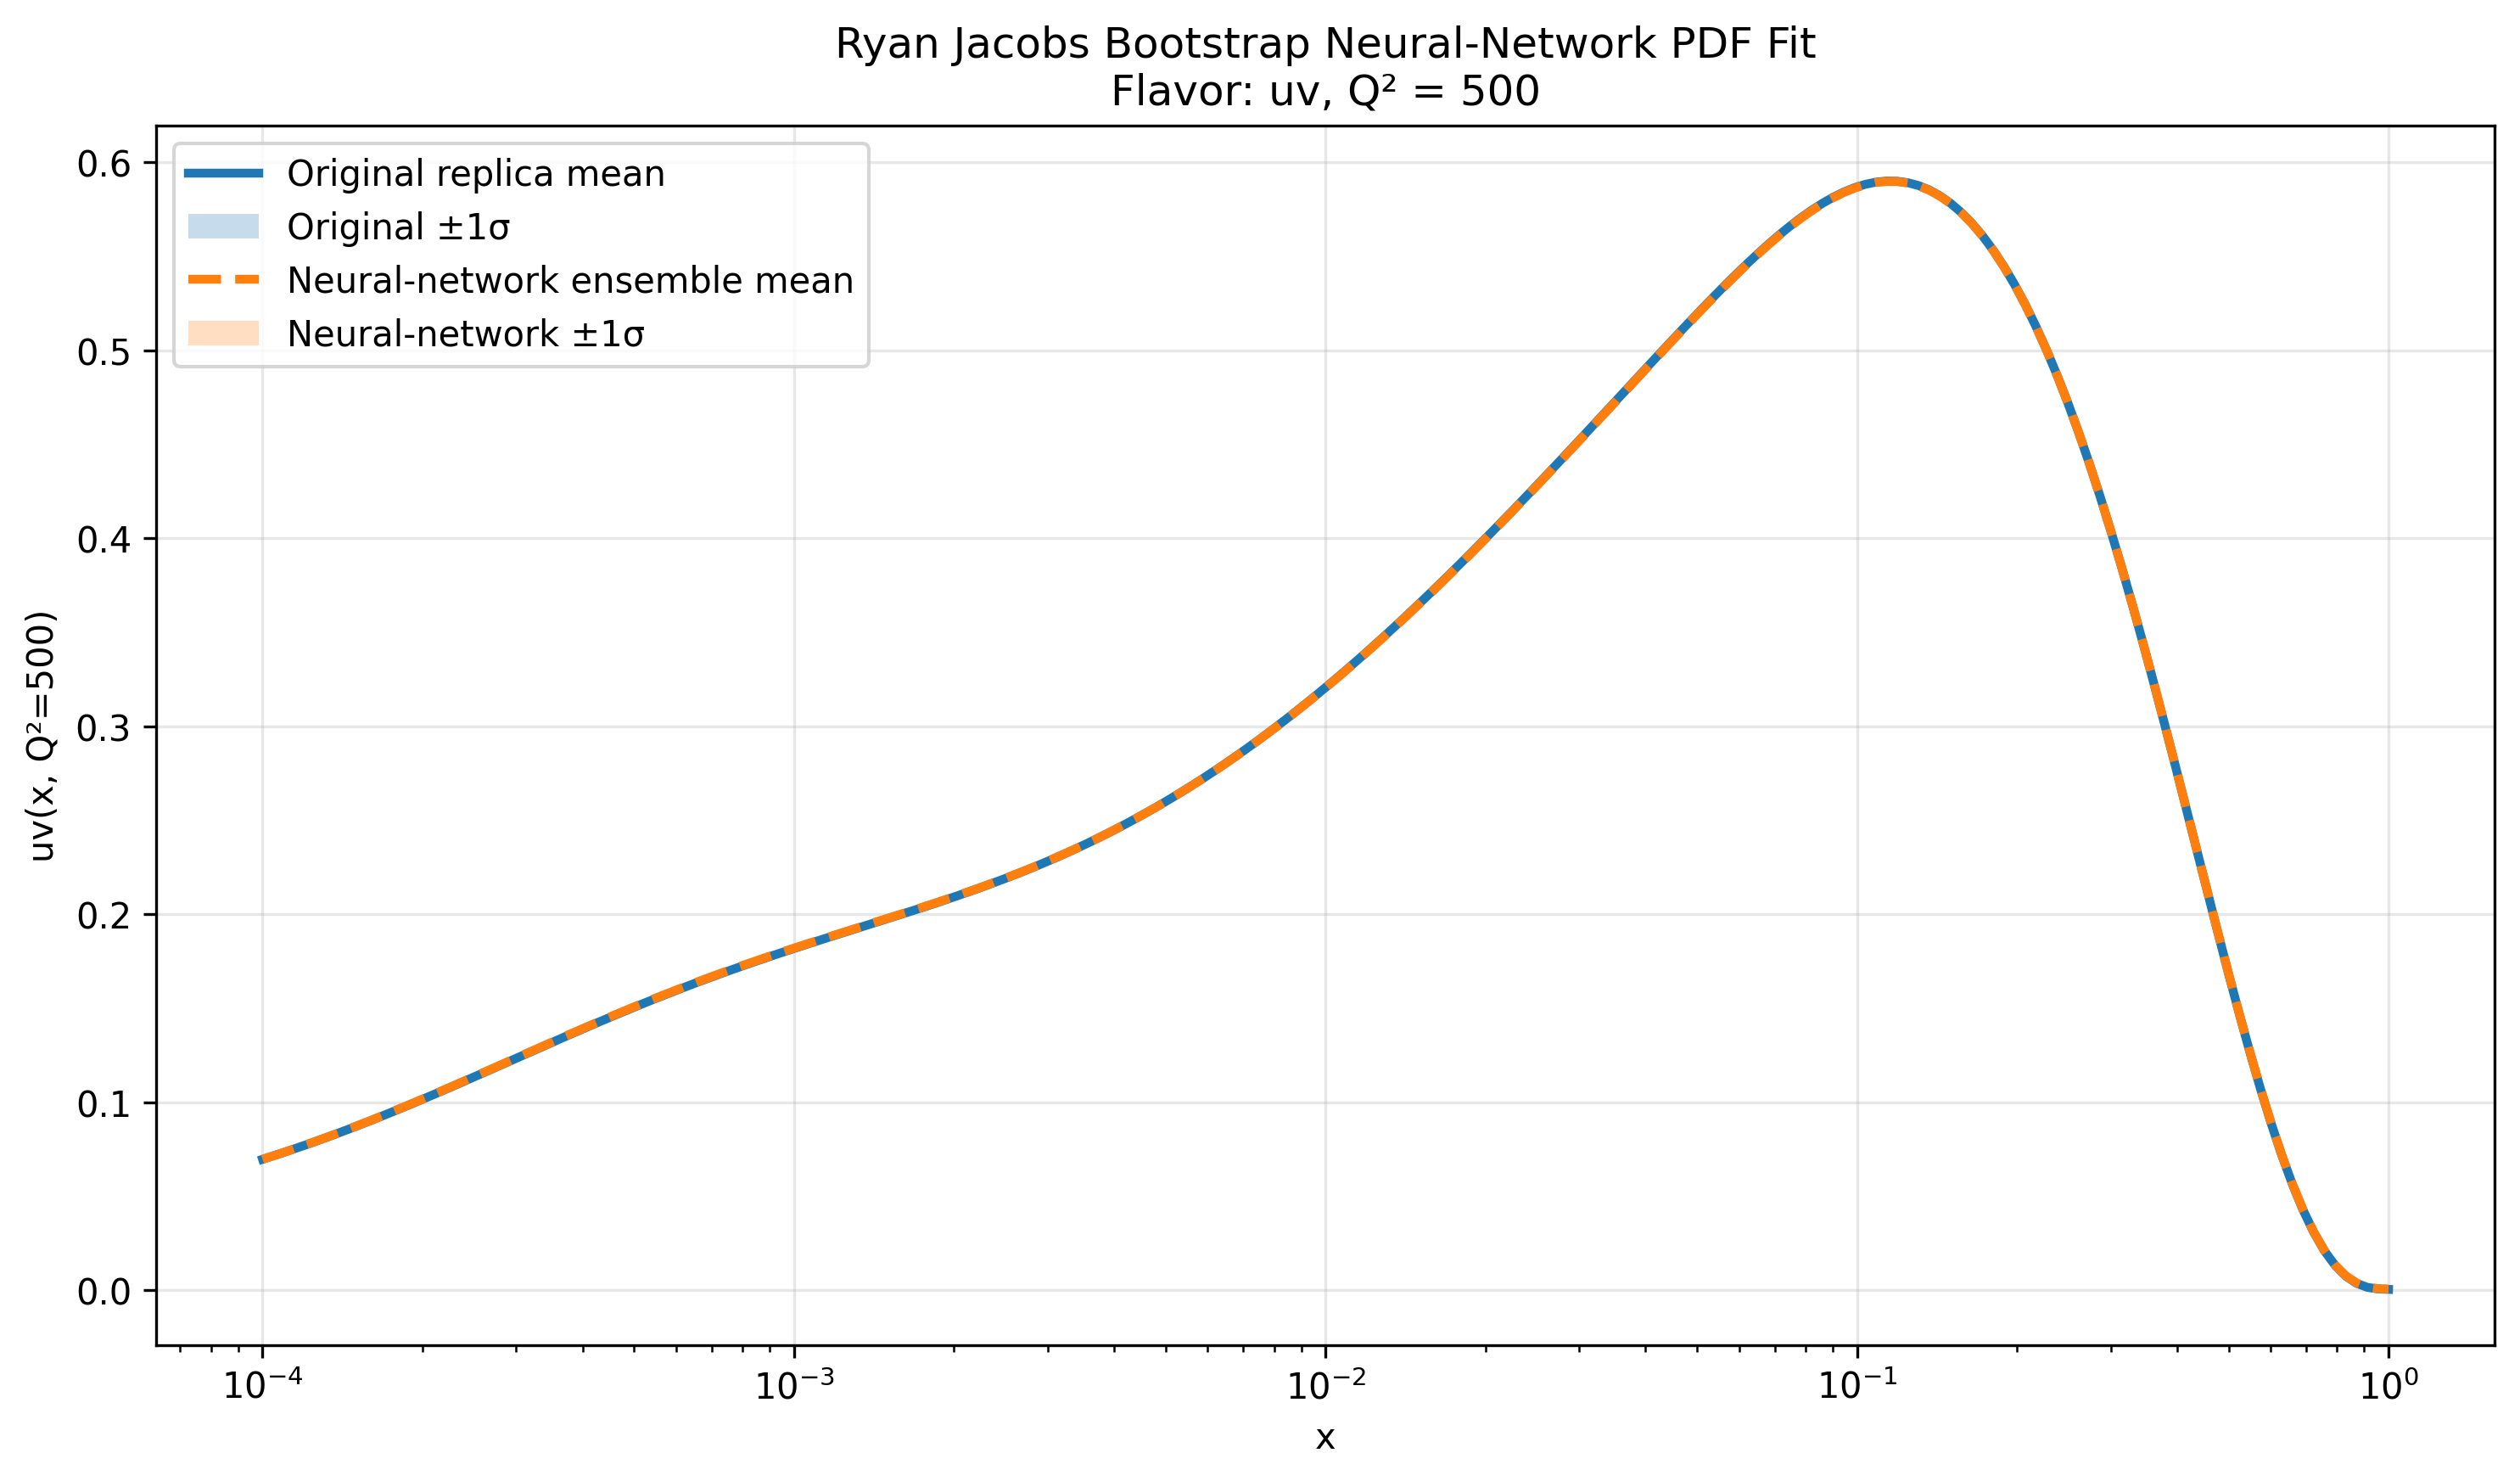

In [ ]:
# Essential graph 1 — Main fit
# This visual is embedded so it will display on GitHub.


## Essential graph 2 — Uncertainty comparison

Original replica standard deviation compared against the neural-network ensemble standard deviation.

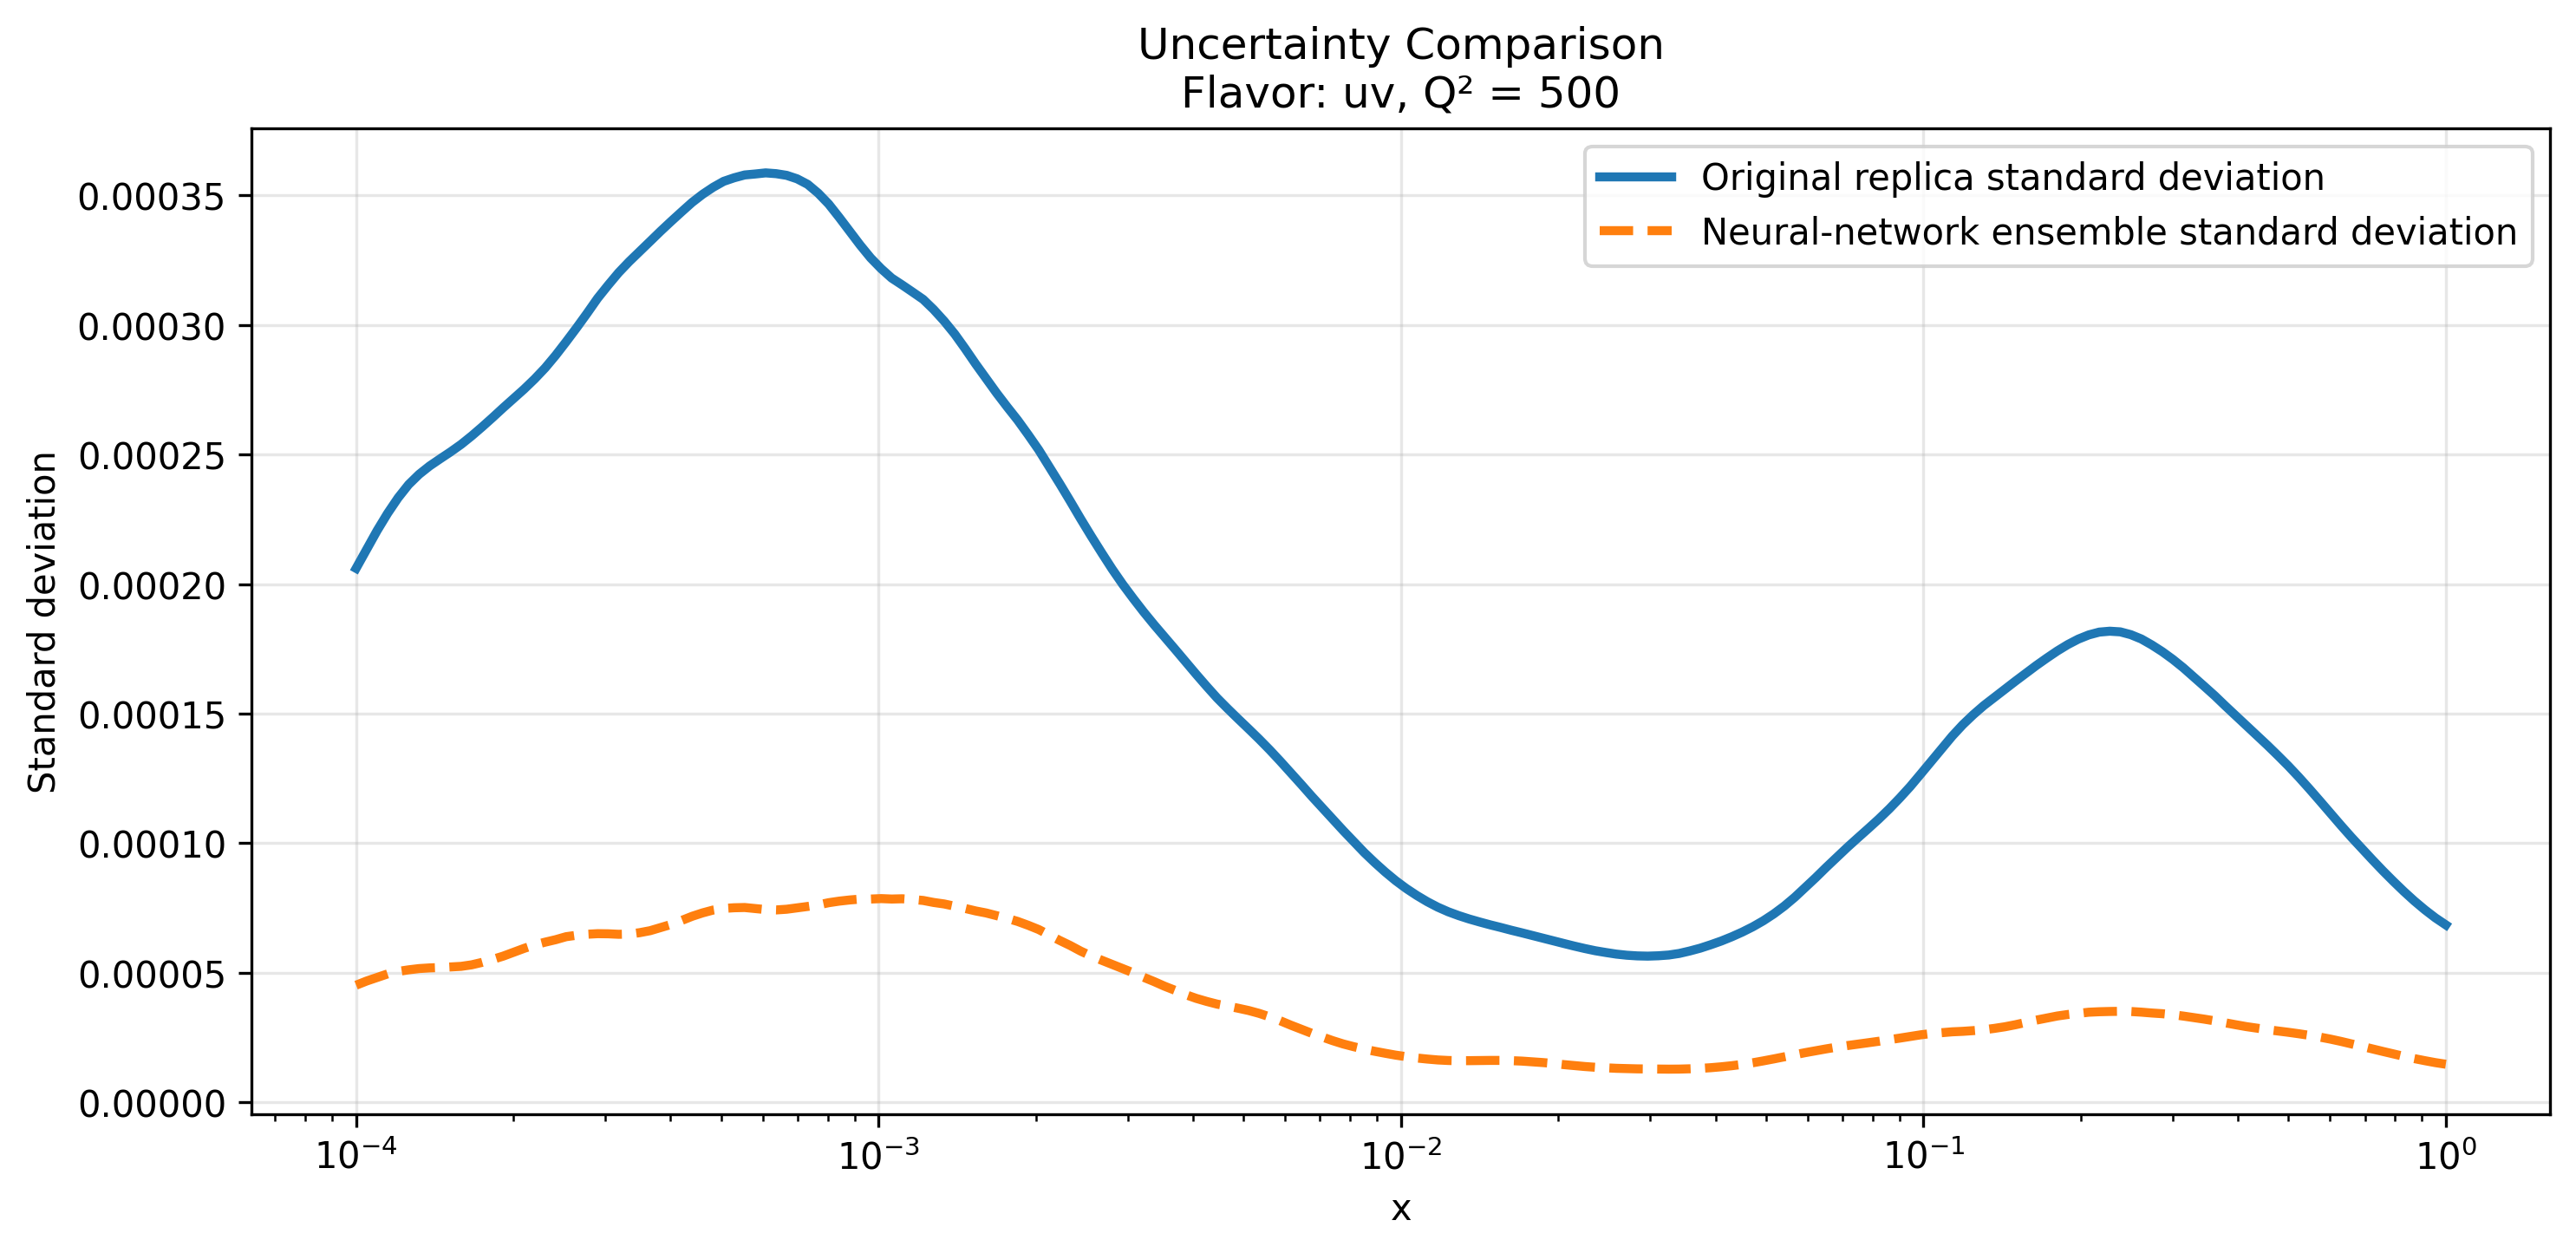

In [ ]:
# Essential graph 2 — Uncertainty comparison
# This visual is embedded so it will display on GitHub.
